The purpose of this notebook is to mimic gravity. If each point on the plane is a unit of mass, or a planet, or something similar, and there are $n$ fixed points of various masses in the plane, and we color each point by where it ends up, then what is the resulting shape?

In [421]:
from IPython.display import HTML
from matplotlib import pyplot as plt
from matplotlib.animation import FuncAnimation
import numpy as np

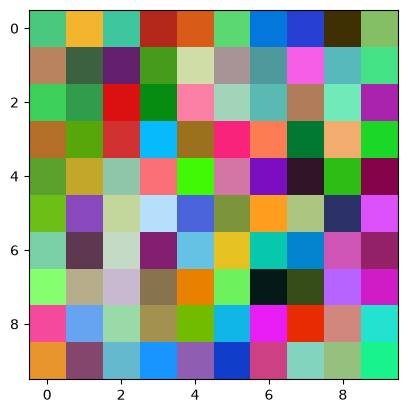

In [422]:
bin_img = np.random.randint(0, 256, (10, 10, 3))

plt.imshow(bin_img)
plt.show()

In [423]:
def determine_resting_pt(pos, fixed_pts, fixed_wts=None, vel=None, vel_decay=0.9, dt=1e-1, time=1e2, eps=2e-1):
    """Determines the final resting point of start_pos.

    Simulates gravity by moving forward by dt units of time.
    Begins by adjusting velocity, then taking a step.

    Returns:
        An integer representing the index of the closest fixed point,
        and the positions of the particle at each step.
    """
    if fixed_wts is None:
        fixed_wts = np.ones(len(fixed_pts))
    if vel is None:
        vel = np.array([0, 0])

    steps = int(time / dt)

    # Fixing type issues
    pos = pos.astype(float)
    fixed_pts = fixed_pts.astype(float)
    vel = vel.astype(float)

    pos_array = np.zeros(shape=(steps, 2))

    for i in range(steps):
        for j, (pt, wt) in enumerate(zip(fixed_pts, fixed_wts)):
            # Updating velocity
            r = np.sqrt(np.sum((pt - pos)**2))

            acc_magn = wt / r**2
            direction = (pt - pos) / r
            vel += dt * acc_magn * direction

            # If a point is "captured", we halt its movement
            if r < eps:
                pos_array[i:] = pt
                return j, pos_array

        # Velocity decay
        vel *= vel_decay

        pos += dt * vel
        pos_array[i] = pos

    # Find the closest fixed point
    return np.argmin(np.linalg.norm(fixed_pts - pos, axis=1)), pos_array

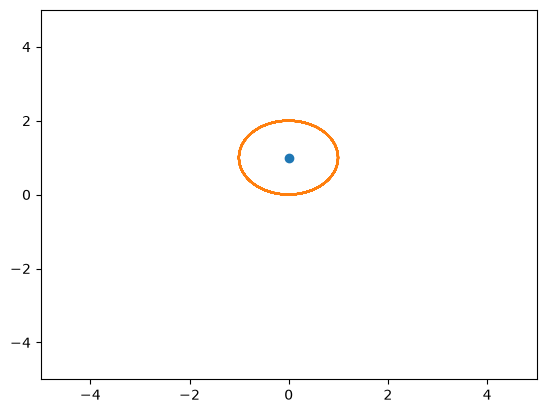

In [424]:
pos = np.array([0, 0])
fixed_pts = np.array([
    [0, 1],
])
vel = np.array([1, 0])
_, motion = determine_resting_pt(pos, fixed_pts, vel=vel, vel_decay=1, dt=1e-2)

n_frames = int(800)
k = int(len(motion) / n_frames)
x_vals, y_vals = motion[:, 0], motion[:, 1]
x_vals = x_vals[::k]
y_vals = y_vals[::k]

# Animating the movement of the point
fig, ax = plt.subplots()
ax.set_xlim(-5, 5)
ax.set_ylim(-5, 5)
for pt in fixed_pts:
    plt.plot(pt[0], pt[1], "o")

line, = ax.plot([], [])

def update(i):
    x, y = x_vals[:i], y_vals[:i]
    line.set_data(x, y)
    return line,

ani = FuncAnimation(fig, update, frames=n_frames, interval=2000/n_frames, blit=True)
HTML(ani.to_jshtml())